In [1]:
import numpy as np
from scipy.io import readsav
import matplotlib.pyplot as plt

from model_spec import *

energy bounds shape (3964,)
energy bounds shape (3964,)


<ErrorbarContainer object of 3 artists>

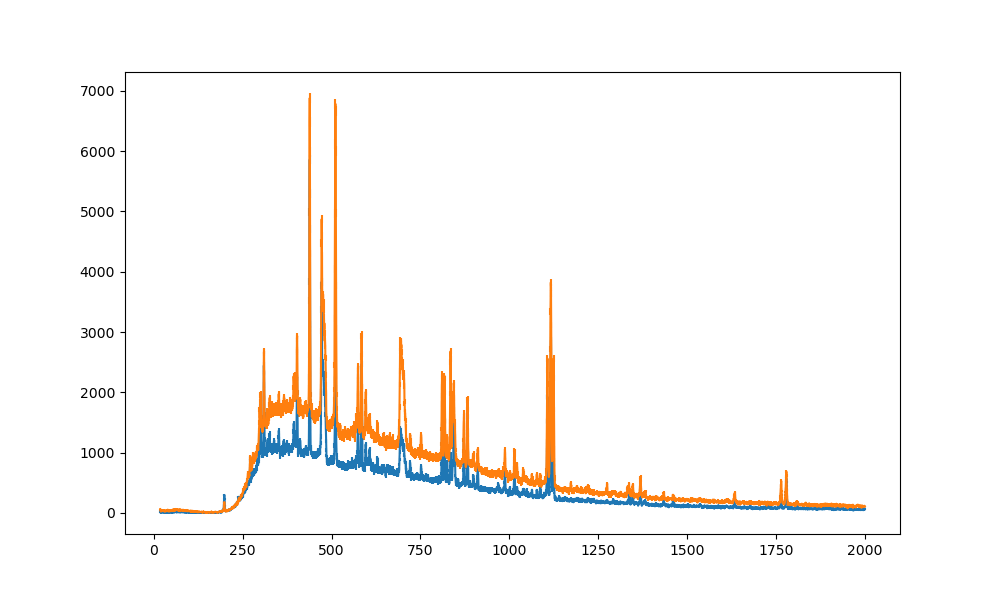

In [10]:
rawspec_sav_path = {
            'PSD':'/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/',
            }

def raw_spec(pid, det):
    '''import raw spectrum over entire energy range'''
    # load spectra file of specific pid, for all 19 detectors
    sav=readsav(f"{rawspec_sav_path['PSD']}/Private_low-rev{pid}.sav")
    # energies in keV
    e_bounds = sav['spi_rev_spectra']['energy_boundaries'][0]
    e_mid = (e_bounds['e_min'] + e_bounds['e_max'])/2
    print('energy bounds shape',e_bounds.shape)
    # spec is a np.record object. it contains a 'counts' and 'stat_err' key
    # both are in units of counts
    spec=sav['spi_rev_spectra']['evts_det_spec'][0][det]
    return spec, e_mid


det=3
# remaining regions to fit: e420_453, e453_490
spec1, e_mid=raw_spec('0043', det)
spec2, _=raw_spec('2000', det)

fig, ax=plt.subplots(1,1,figsize=(10,6))
ax.errorbar(x=e_mid, y=spec1['counts'], yerr=spec1['stat_err'])
ax.errorbar(x=e_mid, y=spec2['counts'], yerr=spec2['stat_err'])

<ErrorbarContainer object of 3 artists>

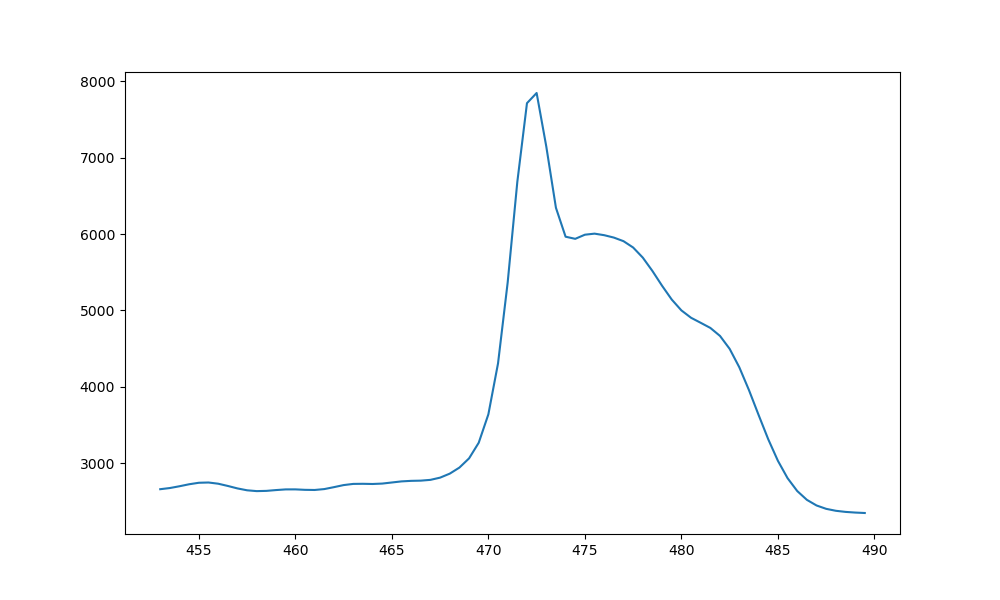

In [9]:
# limits in keV of fit window
e_fit_min, e_fit_max = 453, 490
init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files'
sav_param=readsav(f"{init_param_dir}/init_spec_params_{int(e_fit_min)}_{int(e_fit_max)}_fix.sav")
# name of model
model_name=sav_param['fit_fun'].decode("utf-8")
# create model object
model=BKG_MODELS[model_name](sav_param['xc'])
# chose energy range
e_range=np.arange(e_fit_min, e_fit_max, .5)
# import inital parameters
model.init_params(params=sav_param['left_det'])
# calculate inital flux
init_tot_flux=model.calc_tot(e_range)

%matplotlib widget
fig, ax=plt.subplots(1,1,figsize=(10,6))
ax.errorbar(x=e_range, y=init_tot_flux)

# Fit

In [1]:
from spec_fitter import *

# Initialize the spectrum fitter
e_fit_min, e_fit_max = 453, 490
pid=43
pid_list=np.arange(43,100)
spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
spectrum.get_sumpid_spectrum(pid_list)
# spectrum.get_pid_spectrum(pid)
# spectrum.plot(emin=e_fit_min, emax=e_fit_max)

100%|██████████| 57/57 [00:00<00:00, 63.23it/s]

finished summed spectrum 54/57 revs


(array([ 4635.,  3842.,  3629., ..., 64253., 63886., 63743.],
       shape=(3964,), dtype='>f4'),
 array([ 68.08083 ,  61.983868,  60.24118 , ..., 253.48175 , 252.7568  ,
        252.47375 ], shape=(3964,), dtype=float32),
 array([  18.25,   18.75,   19.25, ..., 1998.75, 1999.25, 1999.75],
       shape=(3964,), dtype=float32),
 rec.array([(   1,   18. ,   18.5), (   2,   18.5,   19. ),
            (   3,   19. ,   19.5), ..., (3962, 1998.5, 1999. ),
            (3963, 1999. , 1999.5), (3964, 1999.5, 2000. )],
           dtype=[(('channel', 'CHANNEL'), '>i4'), (('e_min', 'E_MIN'), '>f4'), (('e_max', 'E_MAX'), '>f4')]))

In [ ]:
from spec_fitter import *
e_fit_min, e_fit_max = 453, 490
det=None
pid=np.arange(43,2000)

spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
spectrum.get_sumpid_spectrum(pid)


100%|██████████| 1957/1957 [00:29<00:00, 65.49it/s]

finished summed spectrum 1808/1957 revs
Model: cls_lin_function


In [ ]:
init_params=np.array([
            2.48589812e+03, -1.51401308e+00,
            # 1.03710274e+02, 4.55449828e+02, 1.27202851e+00, 5.45206372e-04,
            # 7.46836563e+01, 4.59963705e+02, 1.11658739e+00, 1.86258509e-01,
            # 1.53936255e+02, 4.63057869e+02, 1.13519046e+00, 1.46281252e-01,
            # 1.85514471e+02, 4.65680758e+02, 1.24119271e+00, 9.96076013e-02,
            2.76014547e+02, 4.68894384e+02, 1.55598440e+00, 9.86497514e-02,
            5.39734612e+03, 4.72677363e+02, 7.85477991e-01, 8.19161430e-01,
            # 9.58552456e+02, 4.74394463e+02, 1.22396814e+00, 2.52747030e-01,
            1.82996517e+03, 4.75023296e+02, 2.15508256e+00, 2.20245602e-01,
            2.45617114e+03, 4.78012603e+02, 2.07480604e+00, 1.60892252e-01,
            1.92510827e+03, 4.82159411e+02, 1.93228151e+00, 1.80726306e-02
            ])

Model: cls_plaw_function
[SUCCESS] sum_pids
fit_spectrum took 0.030s
Last fit: [True]
--- cont ---
 Cm= 2.0e+07 ± 4.0e+03, alpha= 1.4 ± 0.0
--- lines ---
 E0=  456.4 ±    0.1, A= 8.4e+05 ± 2.4e+04, sig= 1.3e+00 ± 3.3e-02, tau= 5.5e-04 ± 4.2e+04
 E0=  460.0 ±    4.1, A= 6.1e+05 ± 2.7e+05, sig= 1.1e+00 ± 1.0e+00, tau= 1.9e-01 ± 4.9e+00
 E0=  463.1 ±   19.4, A= 1.3e+06 ± 1.1e+06, sig= 1.1e+00 ± 3.7e+00, tau= 1.5e-01 ± 2.3e+01
 E0=  465.7 ±  236.0, A= 1.5e+06 ± 1.5e+07, sig= 1.2e+00 ± 2.0e+01, tau= 1.0e-01 ± 2.5e+02
 E0=  468.9 ± 1134.5, A= 2.2e+06 ± 1.0e+08, sig= 1.6e+00 ± 7.4e+01, tau= 1.0e-01 ± 1.2e+03
 E0=  472.6 ±    0.0, A= 4.4e+07 ± 2.2e+07, sig= 7.3e-01 ± 1.1e-02, tau= 8.4e-01 ± 4.7e-01
 E0=  474.4 ±   10.5, A= 7.8e+06 ± 5.5e+07, sig= 1.2e+00 ± 1.3e+00, tau= 2.5e-01 ± 1.5e+01
 E0=  475.1 ±  486.9, A= 1.5e+07 ± 2.4e+08, sig= 2.1e+00 ± 6.2e+01, tau= 2.2e-01 ± 5.2e+02
 E0=  478.2 ±   95.7, A= 2.0e+07 ± 2.8e+08, sig= 2.0e+00 ± 5.2e+00, tau= 1.6e-01 ± 1.1e+02
 E0=  482.2 ±    2.3, A= 1.

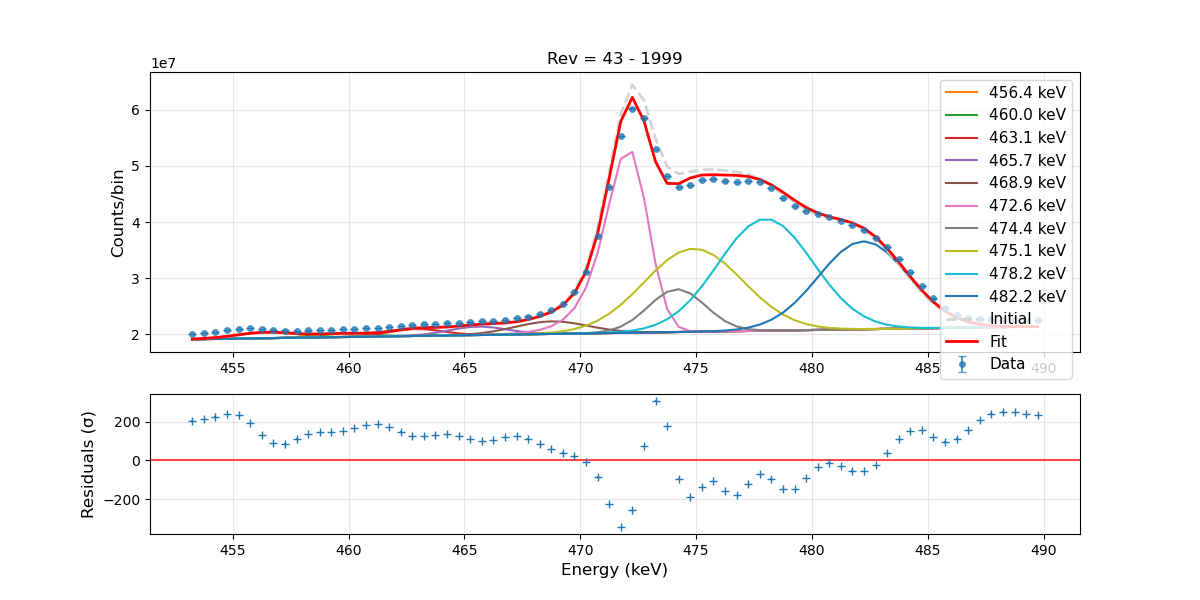

In [3]:
%matplotlib widget
init_params=np.array([
            2.48589812e+03, -1.51401308e+00,
            1.03710274e+02, 4.56449828e+02, 1.27202851e+00, 5.45206372e-04,
            7.46836563e+01, 4.59963705e+02, 1.11658739e+00, 1.86258509e-01,
            1.53936255e+02, 4.63057869e+02, 1.13519046e+00, 1.46281252e-01,
            1.85514471e+02, 4.65680758e+02, 1.24119271e+00, 9.96076013e-02,
            2.76014547e+02, 4.68894384e+02, 1.55598440e+00, 9.86497514e-02,
            5.39734612e+03, 4.72677363e+02, 7.85477991e-01, 8.19161430e-01,
            9.58552456e+02, 4.74394463e+02, 1.22396814e+00, 2.52747030e-01,
            1.82996517e+03, 4.75023296e+02, 2.15508256e+00, 2.20245602e-01,
            2.45617114e+03, 4.78012603e+02, 2.07480604e+00, 1.60892252e-01,
            1.92510827e+03, 4.82159411e+02, 1.93228151e+00, 1.80726306e-02
            ])

fitter = SpectrumFitter(
    spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
    # model_name='cls_lin_function'
)
print(f"Model: {fitter.model_name}")

fitter.fit_spectrum(pid, det, verbose=True, method='scipy', maxfev=10000, init_params=init_params, calc_spec=False)
# fitter.fit_spectrum_mcmc(pid,det, walker_dim_factor=5, nsteps=3000, verbose=True)
fig, axes = fitter.plot_fit(pid, det, show_initial=True, plot_lines=True, show_res=True)
# fitter.fit_results
print(fitter)

[SUCCESS] pid=1000, det=0
fit_spectrum took 2.907s
[Dead Detectors] pid=1000, det=1
fit_spectrum took 0.024s
[Dead Detectors] pid=1000, det=2
fit_spectrum took 0.031s
[SUCCESS] pid=1000, det=3
fit_spectrum took 13.115s
[SUCCESS] pid=1000, det=4
fit_spectrum took 2.806s
[Dead Detectors] pid=1000, det=5
fit_spectrum took 0.041s
[SUCCESS] pid=1000, det=6
fit_spectrum took 2.444s
Fit failed for pid=1000, det=7: Optimal parameters not found: The maximum number of function evaluations is exceeded.
[FAILED] pid=1000, det=7
fit_spectrum took 135.131s
[SUCCESS] pid=1000, det=8
fit_spectrum took 1.782s
Fit failed for pid=1000, det=9: Optimal parameters not found: The maximum number of function evaluations is exceeded.
[FAILED] pid=1000, det=9
fit_spectrum took 126.621s
[SUCCESS] pid=1000, det=10
fit_spectrum took 2.049s
Fit failed for pid=1000, det=11: Optimal parameters not found: The maximum number of function evaluations is exceeded.
[FAILED] pid=1000, det=11
fit_spectrum took 113.234s
Fit fa

/Users/tbastro/Documents/GitHub/spibackground/model_spec.py:41: RuntimeWarning: divide by zero encountered in divide
  return GAUSSCONST * A * np.exp(-(E-E0)**2/ (2*sig**2))


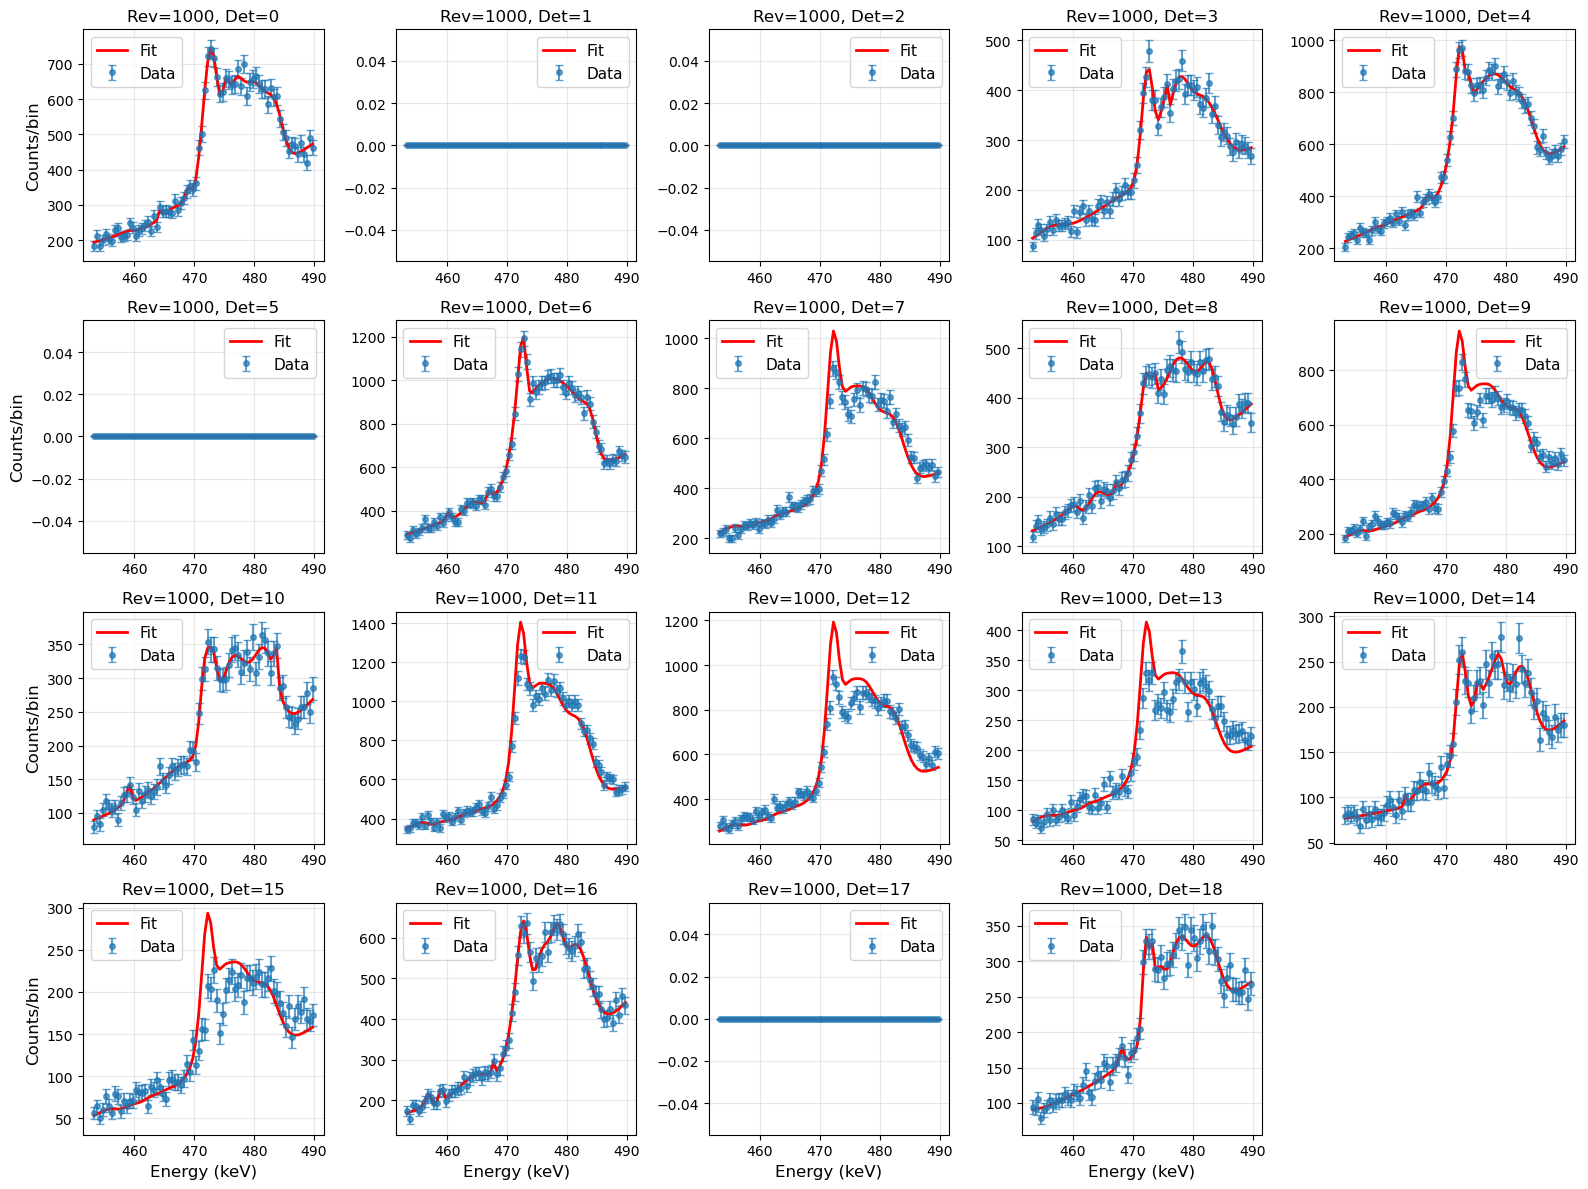

In [2]:
# Fit all detectors for a specific pid
# pid = '1000'
pid = '1000'
results_all_dets = fitter.fit_all_detectors(pid, verbose=True, method='scipy')

print(f"\nFitted {len(results_all_dets)} detectors")
print(f"Successful fits: {sum(1 for r in results_all_dets.values() if r['success'])}")

%matplotlib inline
# # Plot the fitted spectrum
# fig, ax = fitter.plot_fit(pid, det)
# plt.tight_layout()
# plt.show()
fig, axes = fitter.plot_all_detectors(pid)

In [3]:
# Fit all pids (this may take a while)
pid_list = ['0043', '2000']  # Example with multiple pids
all_results = fitter.fit_all_pids(pid_list, verbose=True)

# Get summary statistics
summary = fitter.get_fit_summary()
print(f"\nFit Summary:")
print(f"  Total fits: {summary['total_fits']}")
print(f"  Successful: {summary['successful_fits']}")
print(f"  Failed: {summary['failed_fits']}")
print(f"  Success rate: {summary['success_rate']:.1%}")


[SUCCESS] pid=0043, det=0
[SUCCESS] pid=0043, det=1
[SUCCESS] pid=0043, det=2
[SUCCESS] pid=0043, det=3
[SUCCESS] pid=0043, det=4
[SUCCESS] pid=0043, det=5


KeyboardInterrupt: 

In [8]:
# Fit a single spectrum (1 pid, 1 detector)
pid = '0043'
det = 3

params, perr, success = fitter.fit_spectrum(pid, det, verbose=True)
print(f"\nFitted parameters: {params}")
print(f"Parameter errors: {perr}")


[SUCCESS] pid=0043, det=3

Fitted parameters: [ 1.86150243e+03 -3.74524873e-01  4.69138343e+01  4.55492623e+02
  5.12943267e-02  5.45206372e-04  3.15363690e+01  4.60083868e+02
  1.36528394e-07  7.67393693e-02  7.05289858e+01  4.63079592e+02
  3.71350514e-02  2.05652777e-02  8.45171254e+01  4.65616479e+02
  7.90182699e-03  3.40744947e-02  1.32584810e+02  4.68993527e+02
  1.11016191e-01 -2.58935565e-03  4.05755966e+03  4.72712371e+02
  5.55573956e-01  7.10659068e-01  4.64527352e+02  4.74277500e+02
  3.97914896e-02  4.00013479e-01  1.12326285e+03  4.74905970e+02
  9.51443266e-01  3.11153092e-01  1.61927597e+03  4.77938434e+02
  1.20238489e+00  2.56402797e-01  1.14870521e+03  4.82006116e+02
  1.07613605e+00  1.78328949e-01]
Parameter errors: [inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf]


/Users/tbastro/Documents/GitHub/spibackground/spec_fitter.py:118: OptimizeWarning: Covariance of the parameters could not be estimated
  results = {}
